# Material de presentacion: detectabilidad de flashes

Este cuaderno sintetiza el material offline ya derivado en `data/derived/studies/` para exponer el estado experimental del proyecto.

**Objetivo cientifico**
- Evaluar hasta donde la cadena experimental actual permite detectar destellos LED cortos.
- Comparar lo que aporta la webcam frente al canal analogico con OP598.
- Mostrar que el flujo dual ya permite medir coincidencia entre ambos canales.

**Marco de interpretacion**
- El montaje con LED rojo funciona como analogo controlado de detectabilidad, no como replica completa de una curva de Lissajous real.
- La webcam USB NO es una camara de alta velocidad.
- El camino OP598 + ESP32 + MicroPython entrega tiempos practicos utiles, pero con resolucion temporal gruesa para pulsos rapidos.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image as DisplayImage, Markdown, display

CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = None
for candidate in CANDIDATES:
    if (candidate / ".git").exists() and (candidate / "analysis").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("No se pudo ubicar la raiz del repo para importar modulos de analisis.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from analysis.presentation_notebook import (
    describe_sources,
    export_figure,
    find_repo_root,
    format_percent,
    load_study_tables,
    reconstruction_dir,
    setup_notebook_style,
    success_runs,
)

setup_notebook_style()
REPO_ROOT = find_repo_root(REPO_ROOT)
tables = load_study_tables(REPO_ROOT)

webcam_intensity = tables["webcam_intensity"]
webcam_exposure = tables["webcam_exposure"]
webcam_duration = tables["webcam_duration"]
op598_runs = tables["op598_runs"]
op598_duty = tables["op598_duty"]
op598_duration = tables["op598_duration"]
dual_runs = tables["dual_runs"]
dual_overall = tables["dual_overall"]
reconstruction_base = reconstruction_dir(REPO_ROOT)

print(f"Repo root: {REPO_ROOT}")
print(f"Tablas derivadas cargadas: {len(tables)}")


Repo root: /home/juanm/SensorArray-for-laser-Lissajous-curves
Tablas derivadas cargadas: 8


## Fuentes de datos usadas

El notebook se apoya en artefactos ya agregados por la pipeline offline. Eso reduce friccion al re-ejecutarlo y evita depender de archivos crudos dispersos.


In [2]:
sources = describe_sources(REPO_ROOT, tables)
display(sources)

display(
    Markdown(
        "**Takeaway.** Todo el analisis de esta presentacion sale de `data/derived/studies/`; si esos CSV se regeneran con `python scripts/build_study_summaries.py`, el cuaderno queda actualizado sin tocar hardware."
    )
)


,tabla,archivo,filas,columnas
0,webcam_intensity,data/derived/studies/webcam_intensity_by_duty.csv,20,9
1,webcam_exposure,data/derived/studies/webcam_parameter_by_expos...,11,8
2,webcam_duration,data/derived/studies/webcam_parameter_by_durat...,16,8
3,op598_runs,data/derived/studies/op598_characterization_ru...,10,18
4,op598_duty,data/derived/studies/op598_characterization_by...,5,6
5,op598_duration,data/derived/studies/op598_characterization_by...,4,6
6,dual_runs,data/derived/studies/dual_random_train_runs.csv,11,19
7,dual_overall,data/derived/studies/dual_random_train_overall...,2,4


**Takeaway.** Todo el analisis de esta presentacion sale de `data/derived/studies/`; si esos CSV se regeneran con `python scripts/build_study_summaries.py`, el cuaderno queda actualizado sin tocar hardware.

## Detectabilidad webcam vs duty

Primera pregunta: con la configuracion actual, que nivel de excitacion LED empieza a producir deteccion confiable en la webcam?


,duty,replicates,mean_detection_probability,median_detection_probability,detected_runs,expected_total_pulses,detected_total_events,bounded_detected_total,mean_detected_frames
0,1,1,0.0,0.0,0,3,0,0,0.000
1,2,1,0.0,0.0,0,3,0,0,0.000
2,4,1,0.0,0.0,0,3,0,0,0.000
3,6,1,1.0,1.0,1,3,3,3,14.000
4,8,3,1.0,1.0,3,9,9,9,17.667
5,10,1,1.0,1.0,1,3,3,3,18.000
6,12,1,1.0,1.0,1,3,3,3,18.000
7,16,3,1.0,1.0,3,9,9,9,18.000
8,24,3,1.0,1.0,3,9,9,9,18.000
9,32,3,1.0,1.0,3,9,9,9,18.000


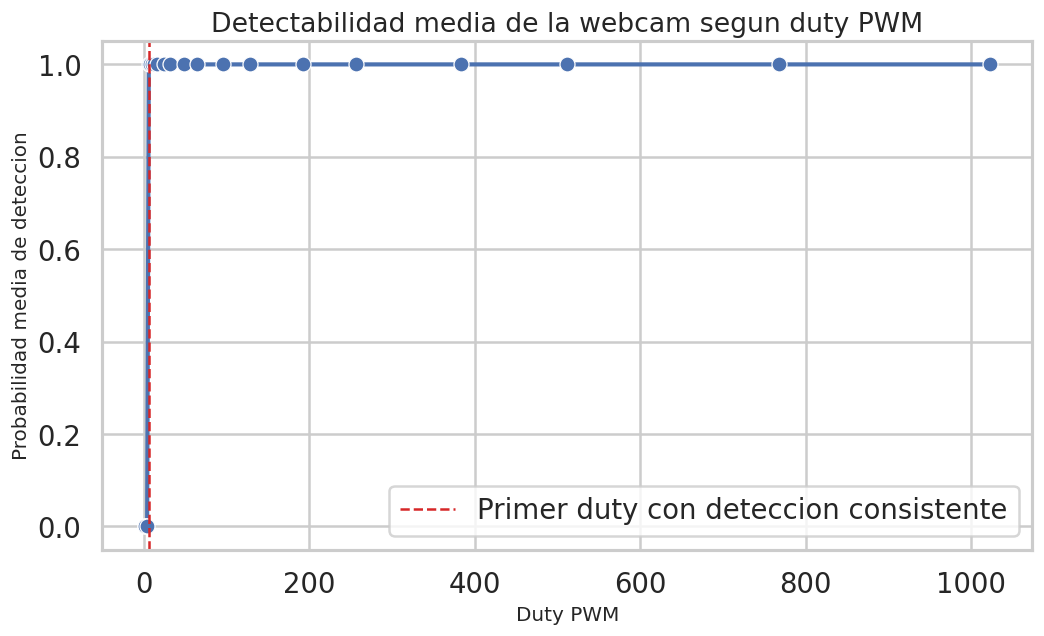

**Takeaway.** En estas corridas heredadas, la webcam pasa de no detectar nada en `duty 1-4` a detectar de forma consistente desde `duty 6`. Esto habla de detectabilidad del pipeline webcam + umbral, NO de una ley radiometrica del LED.

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=webcam_intensity,
    x="duty",
    y="mean_detection_probability",
    marker="o",
    linewidth=2.5,
    ax=ax,
)
ax.set_ylim(-0.05, 1.05)
ax.set_title("Detectabilidad media de la webcam segun duty PWM")
ax.set_xlabel("Duty PWM")
ax.set_ylabel("Probabilidad media de deteccion")
ax.axvline(6, color="tab:red", linestyle="--", linewidth=1.5, label="Primer duty con deteccion consistente")
ax.legend()
display(webcam_intensity)
display(fig)
export_figure(fig, REPO_ROOT, "webcam_detectability_vs_duty.png")
plt.close(fig)

threshold = webcam_intensity.loc[webcam_intensity["mean_detection_probability"] >= 0.5].sort_values("duty").iloc[0]
display(
    Markdown(
        f"**Takeaway.** En estas corridas heredadas, la webcam pasa de no detectar nada en `duty 1-4` a detectar de forma consistente desde `duty {int(threshold['duty'])}`. Esto habla de detectabilidad del pipeline webcam + umbral, NO de una ley radiometrica del LED."
    )
)


## Detectabilidad webcam vs duracion y exposicion

Ahora separamos dos perillas experimentales distintas:
- `duracion_ms`: cuanto dura el pulso LED.
- `exposure`: cuanto integra la webcam cada cuadro.

La idea es mostrar donde aparece detectabilidad, y donde esa detectabilidad puede venir de integrar mas luz en el frame en vez de resolver mejor el instante del pulso.


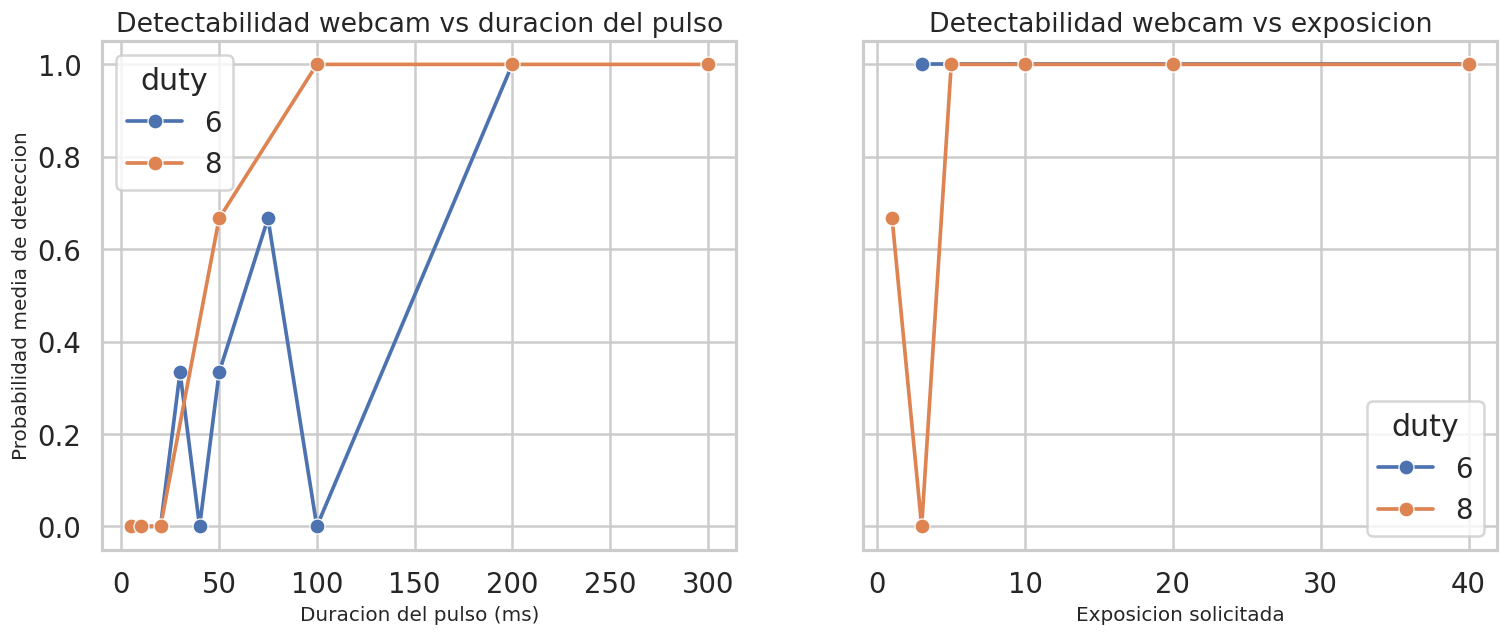

,duty,duration_ms,mean_detection_probability
0,6,75,0.666667
1,8,50,0.666667


,exposure,mean_detection_probability
5,1.0,0.666667
6,3.0,0.000000
7,5.0,1.000000


**Takeaway.** Para la webcam, los pulsos cortos siguen siendo dificiles: la primera condicion >=50% aparece en `duty 6` recien a `75 ms`, y en `duty 8` a `50 ms`. Subir exposicion ayuda a que aparezca el destello en el frame, pero no convierte a la webcam en un sensor temporal rapido.

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

sns.lineplot(
    data=webcam_duration,
    x="duration_ms",
    y="mean_detection_probability",
    hue="duty",
    marker="o",
    linewidth=2.2,
    palette="deep",
    ax=axes[0],
)
axes[0].set_title("Detectabilidad webcam vs duracion del pulso")
axes[0].set_xlabel("Duracion del pulso (ms)")
axes[0].set_ylabel("Probabilidad media de deteccion")
axes[0].set_ylim(-0.05, 1.05)

sns.lineplot(
    data=webcam_exposure,
    x="exposure",
    y="mean_detection_probability",
    hue="duty",
    marker="o",
    linewidth=2.2,
    palette="deep",
    ax=axes[1],
)
axes[1].set_title("Detectabilidad webcam vs exposicion")
axes[1].set_xlabel("Exposicion solicitada")
axes[1].set_ylabel("")
axes[1].set_ylim(-0.05, 1.05)

display(fig)
export_figure(fig, REPO_ROOT, "webcam_duration_exposure_summary.png")
plt.close(fig)

duration_thresholds = (
    webcam_duration.loc[webcam_duration["mean_detection_probability"] >= 0.5]
    .sort_values(["duty", "duration_ms"])
    .groupby("duty", as_index=False)
    .first()[["duty", "duration_ms", "mean_detection_probability"]]
)
display(duration_thresholds)

low_exposure_gap = webcam_exposure.loc[
    (webcam_exposure["duty"] == 8) & (webcam_exposure["exposure"] <= 5),
    ["exposure", "mean_detection_probability"],
]
display(low_exposure_gap)

duty6 = duration_thresholds.loc[duration_thresholds["duty"] == 6, "duration_ms"].iloc[0]
duty8 = duration_thresholds.loc[duration_thresholds["duty"] == 8, "duration_ms"].iloc[0]
display(
    Markdown(
        f"**Takeaway.** Para la webcam, los pulsos cortos siguen siendo dificiles: la primera condicion >=50% aparece en `duty 6` recien a `{int(duty6)} ms`, y en `duty 8` a `{int(duty8)} ms`. Subir exposicion ayuda a que aparezca el destello en el frame, pero no convierte a la webcam en un sensor temporal rapido."
    )
)


## Caracterizacion OP598 y saturacion

El canal analogico con OP598 aporta una vista distinta: amplitud ADC, ancho efectivo del pulso reconstruido y una referencia temporal practica de la cadena numerica.


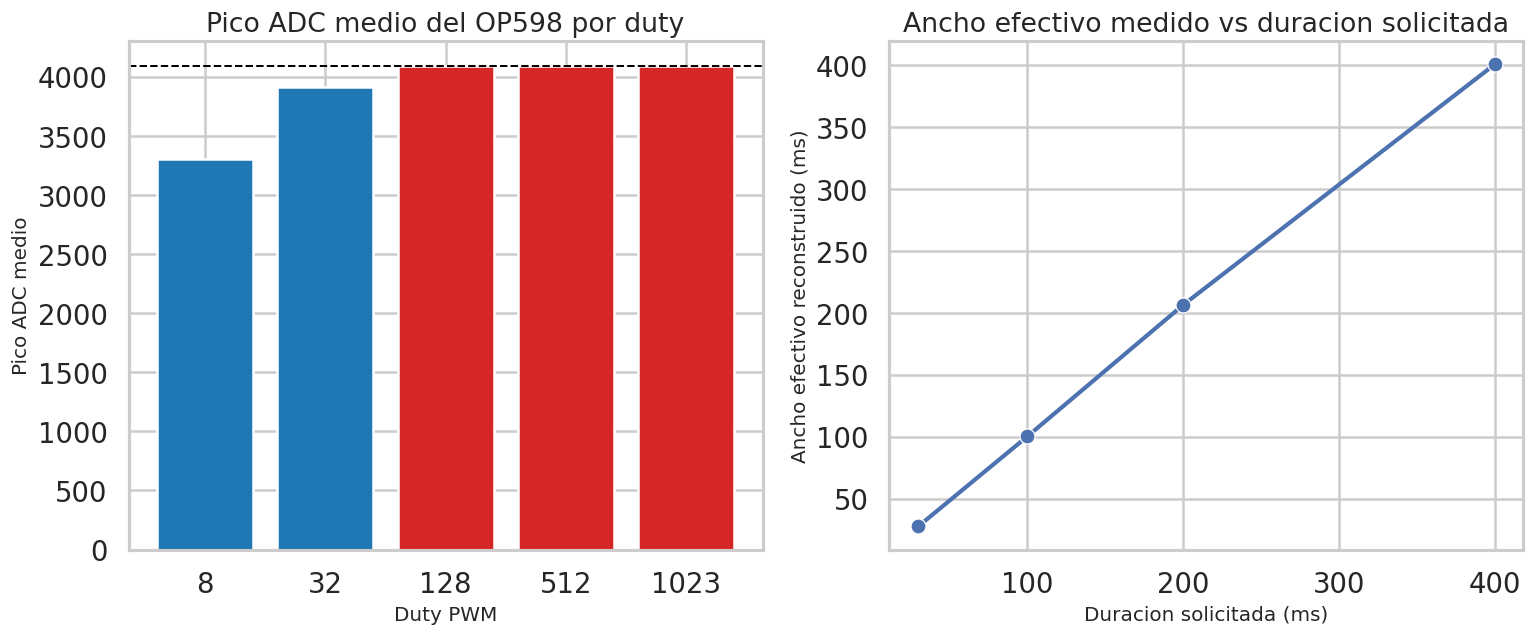

,duty,replicates,mean_peak_adc,mean_peak_minus_baseline,all_saturated,any_saturated
0,8,1,3307.0,326.153846,False,False
1,32,1,3915.0,935.923077,False,False
2,128,1,4095.0,1177.000000,True,True
3,512,1,4095.0,1234.846154,True,True
4,1023,1,4095.0,1182.307692,True,True


,duration_ms,replicates,mean_peak_adc,median_peak_adc,mean_pulse_width_ms,any_saturated
0,30,1,4095.0,4095.0,27.538,True
1,100,1,4095.0,4095.0,100.147,True
2,200,1,4095.0,4095.0,206.311,True
3,400,1,4095.0,4095.0,400.594,True


**Takeaway.** El canal OP598 muestra respuesta util antes de saturar en `duty 8-32`, pero desde `duty 128` pega al techo de `4095`. Ademas, el muestreo medio observado ronda `6.73 ms`, asi que el sistema entrega tiempos practicos gruesos bajo MicroPython, no metrologia ultrarrapida del fototransistor.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

saturation_labels = op598_duty["all_saturated"].astype(str).str.lower()
duty_colors = saturation_labels.map({"true": "tab:red", "false": "tab:blue"})
axes[0].bar(op598_duty["duty"].astype(str), op598_duty["mean_peak_adc"], color=duty_colors)
axes[0].axhline(4095, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Pico ADC medio del OP598 por duty")
axes[0].set_xlabel("Duty PWM")
axes[0].set_ylabel("Pico ADC medio")

sns.lineplot(
    data=op598_duration,
    x="duration_ms",
    y="mean_pulse_width_ms",
    marker="o",
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title("Ancho efectivo medido vs duracion solicitada")
axes[1].set_xlabel("Duracion solicitada (ms)")
axes[1].set_ylabel("Ancho efectivo reconstruido (ms)")

display(fig)
export_figure(fig, REPO_ROOT, "op598_saturation_and_width.png")
plt.close(fig)

sample_interval_ms = op598_runs["sample_interval_avg_ms"].dropna().mean()
first_saturated = op598_duty.loc[saturation_labels == "true"].sort_values("duty").iloc[0]
display(op598_duty)
display(op598_duration)
display(
    Markdown(
        f"**Takeaway.** El canal OP598 muestra respuesta util antes de saturar en `duty 8-32`, pero desde `duty {int(first_saturated['duty'])}` pega al techo de `4095`. Ademas, el muestreo medio observado ronda `{sample_interval_ms:.2f} ms`, asi que el sistema entrega tiempos practicos gruesos bajo MicroPython, no metrologia ultrarrapida del fototransistor."
    )
)


## Coincidencia dual entre OP598 y webcam

La pregunta aqui no es solo si cada canal detecta algo, sino si ambos pueden alinearse corrida por corrida para estudiar coincidencia de eventos.


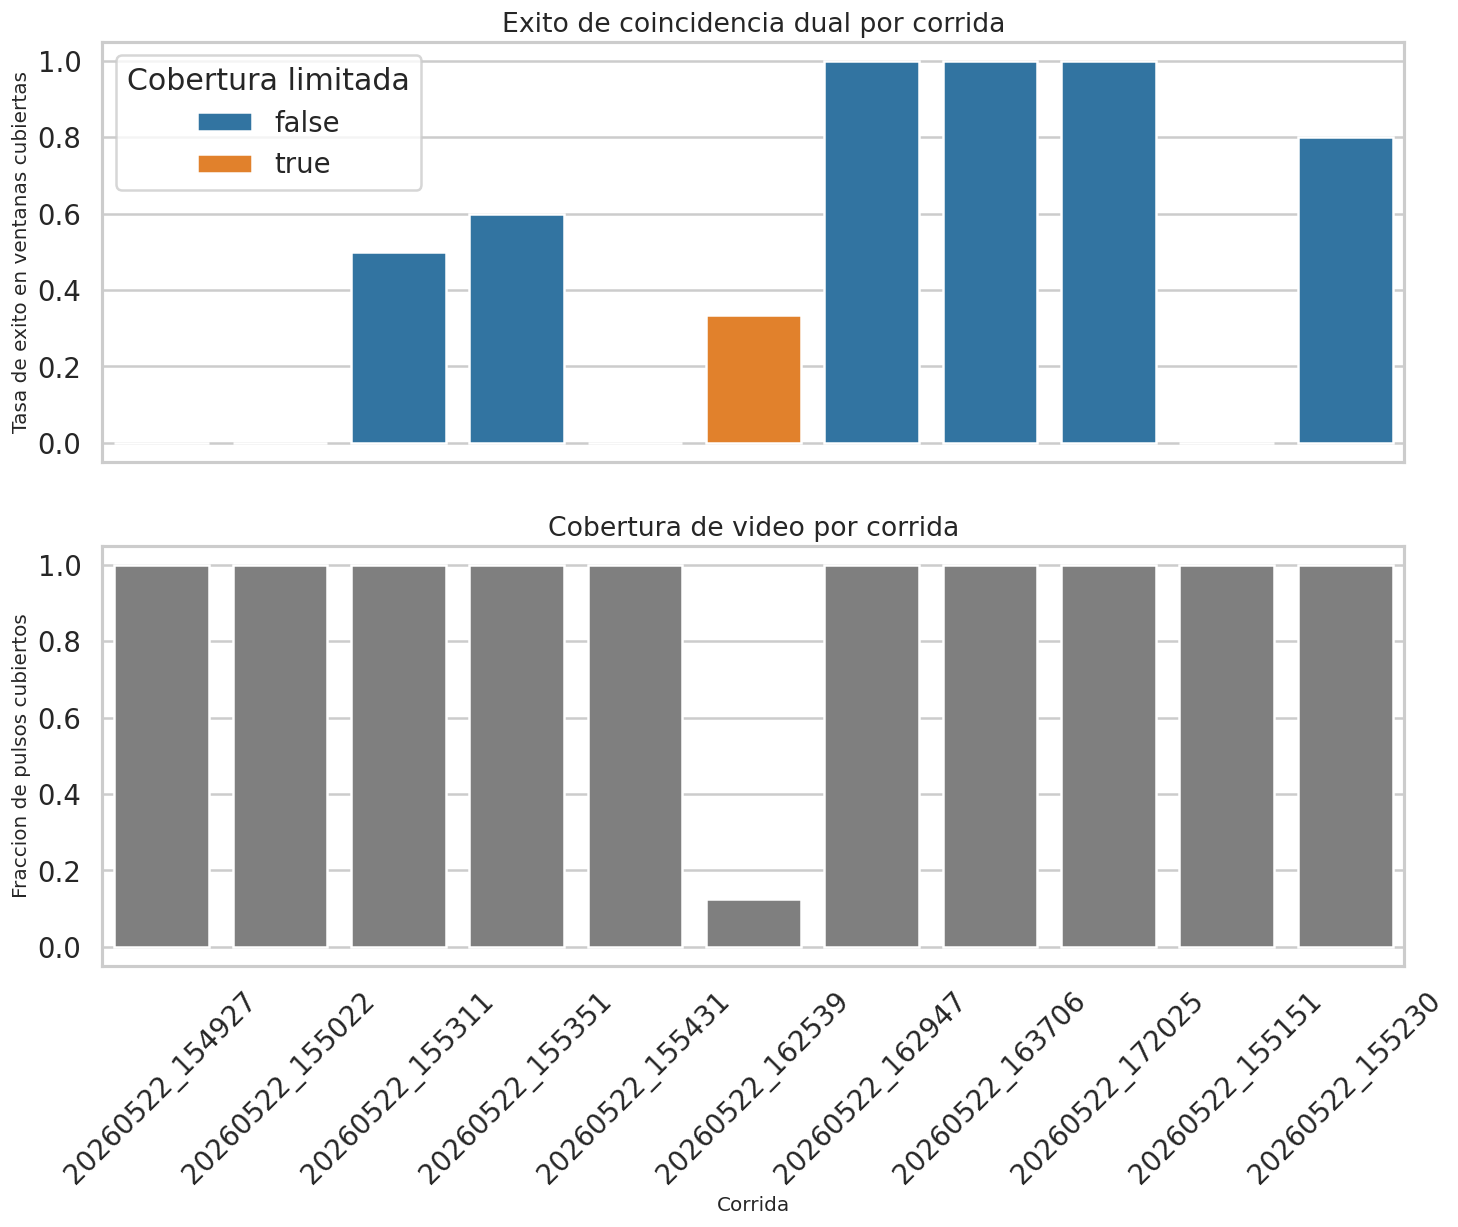

,subset,run_count,mean_windowed_success_rate,mean_all_pulse_success_rate
0,all_runs,11,0.475758,0.449242
1,fully_covered_runs,10,0.490000,0.490000


,run_id,variant,coverage_fraction,coincidence_success_rate_windowed,mean_offset_ms_detected
6,random-train_20260522_162947,phase2_statistical_reconstruction_matrix,1.0,1.0,39.397036
7,random-train_20260522_163706,phase2_statistical_reconstruction_matrix,1.0,1.0,32.111678
8,random-train_20260522_172025,phase2_statistical_reconstruction_matrix,1.0,1.0,39.444915
10,random-train_20260522_155230,phase2_statistical_reconstruction_probe,1.0,0.8,-10.927491


**Takeaway.** El flujo dual YA permite cuantificar coincidencia: en corridas con cobertura completa, la tasa media de exito en ventanas cubiertas es `49.0%`. Pero hay `1` corrida(s) de `11` con video incompleto, y eso obliga a separar exito sobre ventanas cubiertas de exito sobre todos los pulsos.

In [6]:
dual_runs_plot = dual_runs.copy()
dual_runs_plot["run_short"] = dual_runs_plot["run_id"].str.replace("random-train_", "", regex=False)
dual_runs_plot["limited_coverage_label"] = dual_runs_plot["limited_coverage"].astype(str).str.lower()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.barplot(
    data=dual_runs_plot,
    x="run_short",
    y="coincidence_success_rate_windowed",
    hue="limited_coverage_label",
    palette={"false": "tab:blue", "true": "tab:orange"},
    ax=axes[0],
)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title("Exito de coincidencia dual por corrida")
axes[0].set_xlabel("")
axes[0].set_ylabel("Tasa de exito en ventanas cubiertas")
axes[0].legend(title="Cobertura limitada")

sns.barplot(
    data=dual_runs_plot,
    x="run_short",
    y="coverage_fraction",
    color="tab:gray",
    ax=axes[1],
)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Cobertura de video por corrida")
axes[1].set_xlabel("Corrida")
axes[1].set_ylabel("Fraccion de pulsos cubiertos")
axes[1].tick_params(axis="x", rotation=45)

display(fig)
export_figure(fig, REPO_ROOT, "dual_coincidence_and_coverage.png")
plt.close(fig)

display(dual_overall)
best_runs = success_runs(dual_runs).sort_values("coincidence_success_rate_windowed", ascending=False)
display(best_runs[["run_id", "variant", "coverage_fraction", "coincidence_success_rate_windowed", "mean_offset_ms_detected"]])

full_coverage = dual_overall.loc[dual_overall["subset"] == "fully_covered_runs", "mean_windowed_success_rate"].iloc[0]
limited = int((dual_runs["limited_coverage"].astype(str).str.lower() == "true").sum())
total = int(len(dual_runs))
display(
    Markdown(
        f"**Takeaway.** El flujo dual YA permite cuantificar coincidencia: en corridas con cobertura completa, la tasa media de exito en ventanas cubiertas es `{format_percent(full_coverage)}`. Pero hay `{limited}` corrida(s) de `{total}` con video incompleto, y eso obliga a separar exito sobre ventanas cubiertas de exito sobre todos los pulsos."
    )
)


## Reconstruccion estadistica y slow motion proxy

Esta parte SIEMPRE hay que leerla con disciplina conceptual: no estamos viendo video rapido real del flash. Estamos apilando muchas coincidencias buenas para construir una proxy visual acumulada del evento.


,selection_rank,run_id,variant,covered_pulses,matched_detected,coincidence_success_rate_windowed,mean_offset_ms_detected
0,1.0,random-train_20260522_172025,phase2_statistical_reconstruction_matrix,10,10,1.0,39.444915
1,2.0,random-train_20260522_163706,phase2_statistical_reconstruction_matrix,10,10,1.0,32.111678
2,3.0,random-train_20260522_162947,phase2_statistical_reconstruction_matrix,10,10,1.0,39.397036


,group_type,group_id,run_id,variant,phase_offset,phase_label,frame_count,matched_pulses,effective_sample_size,covered_pulses,...,coincidence_success_ci_low,coincidence_success_ci_high,mean_offset_ms_detected,offset_std_ms_detected,frame_mean_gray,frame_p95_gray,delta_mean_gray_vs_before,delta_abs_mean_gray_vs_before,positive_delta_fraction_vs_before,preview_path
0,pooled,pooled,NaN,selected_runs_pool,-2,before,30,30,3.0,30,...,0.886483,1.0,36.984543,10.074621,0.333333,0.333333,0.000000,0.000000,0.000000,data/derived/reconstruction/phase_averages/poo...
1,pooled,pooled,NaN,selected_runs_pool,-1,approach,30,30,3.0,30,...,0.886483,1.0,36.984543,10.074621,0.333333,0.333333,0.000000,0.000000,0.000000,data/derived/reconstruction/phase_averages/poo...
2,pooled,pooled,NaN,selected_runs_pool,0,hit,30,30,3.0,30,...,0.886483,1.0,36.984543,10.074621,0.370902,0.333333,0.037568,0.038588,0.005745,data/derived/reconstruction/phase_averages/poo...
3,pooled,pooled,NaN,selected_runs_pool,1,decay,30,30,3.0,30,...,0.886483,1.0,36.984543,10.074621,0.342382,0.333333,0.009048,0.010092,0.004284,data/derived/reconstruction/phase_averages/poo...
4,pooled,pooled,NaN,selected_runs_pool,2,after,30,30,3.0,30,...,0.886483,1.0,36.984543,10.074621,0.333333,0.333333,0.000000,0.000000,0.000000,data/derived/reconstruction/phase_averages/poo...


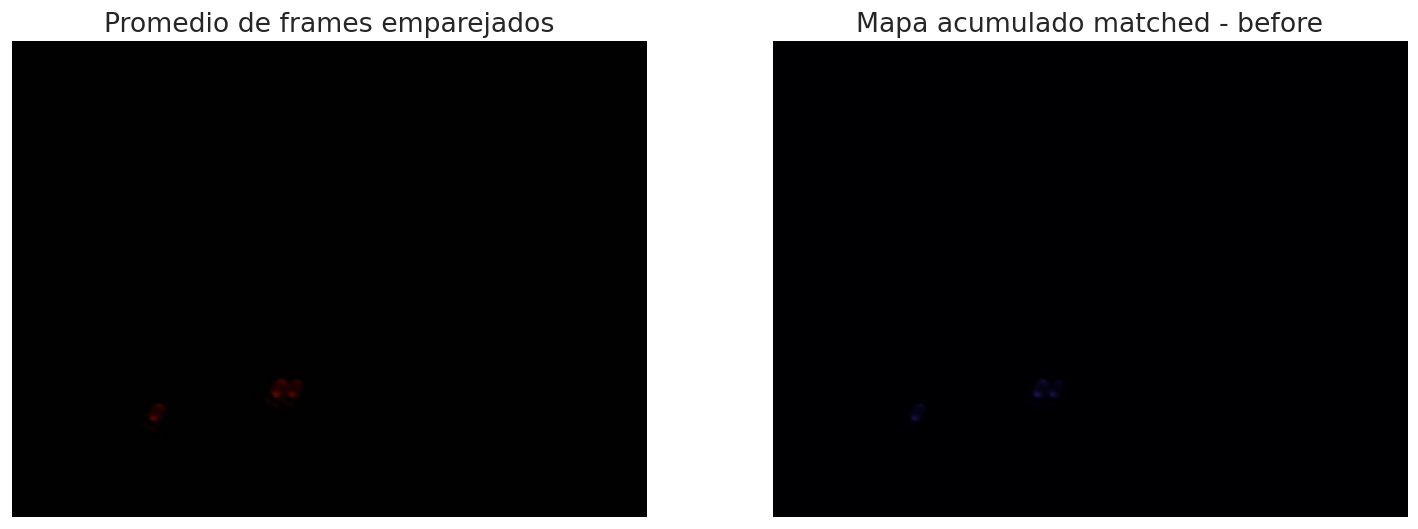

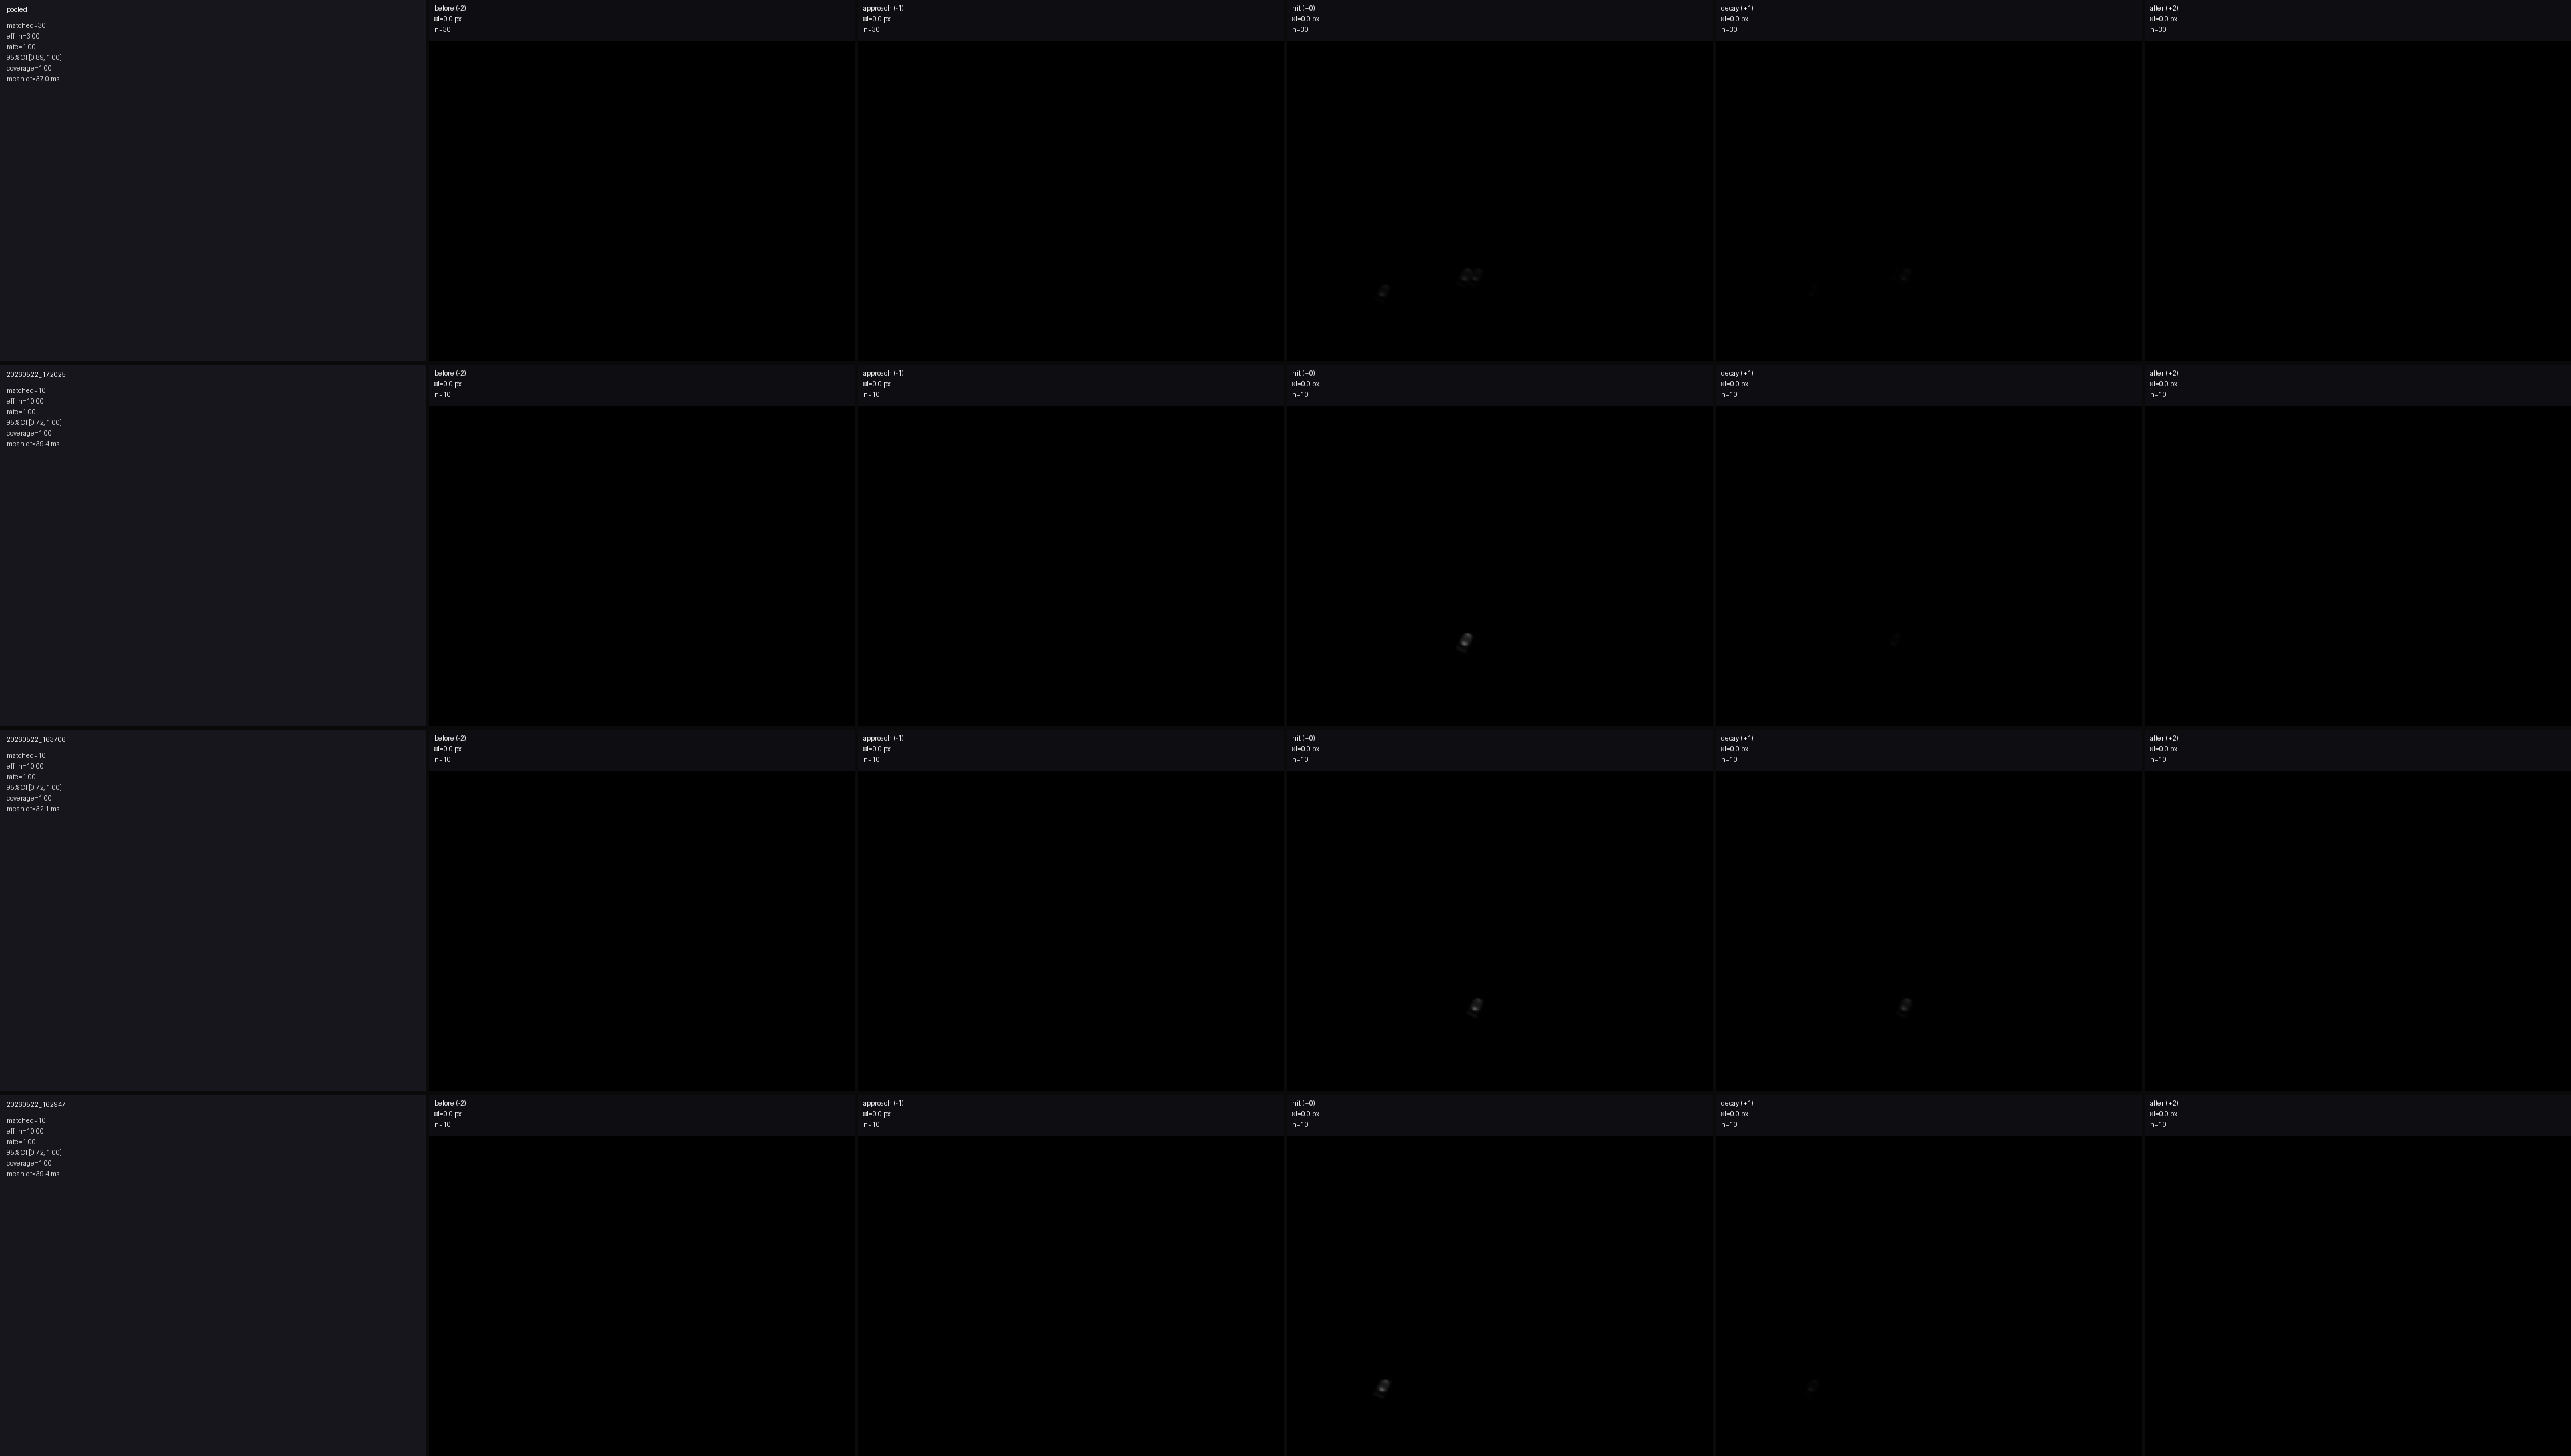

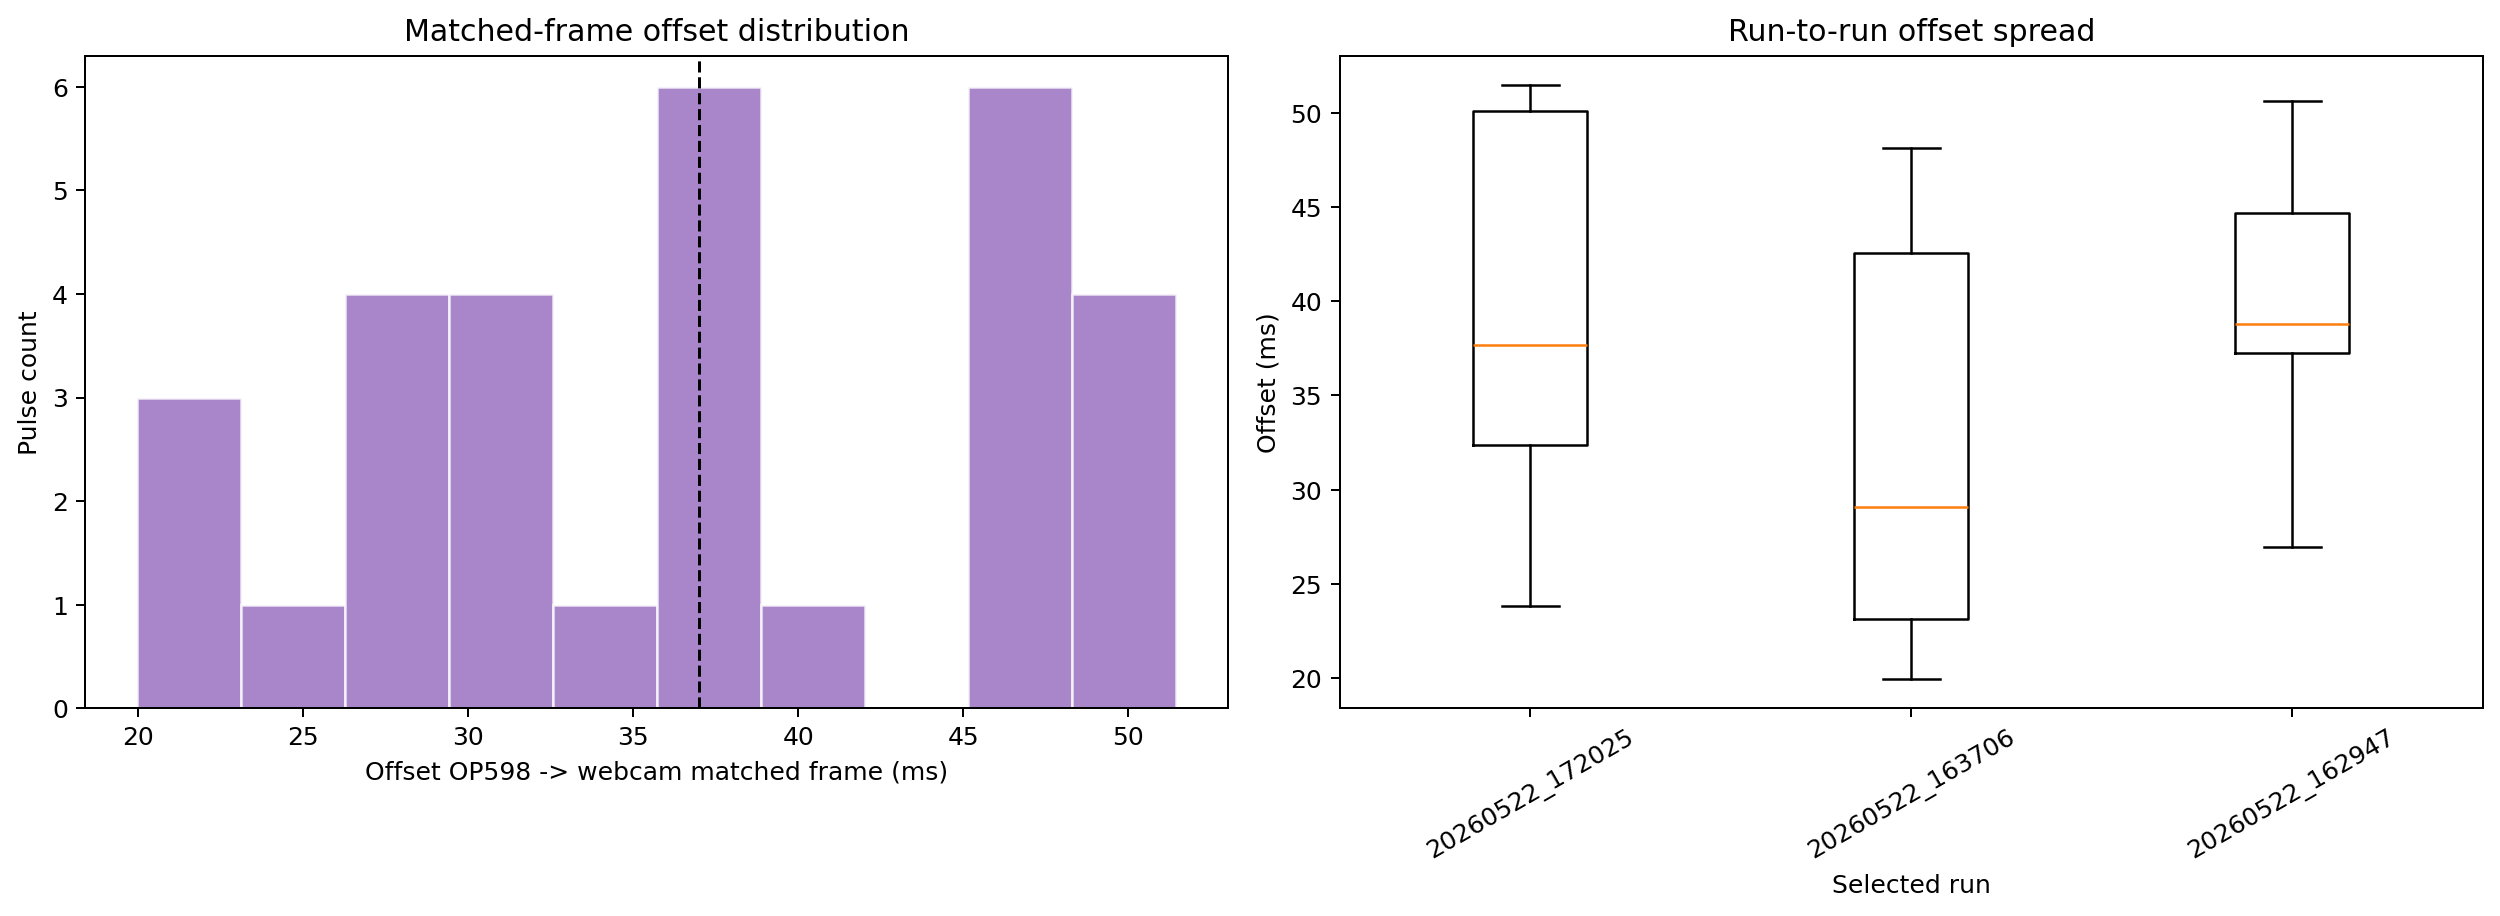

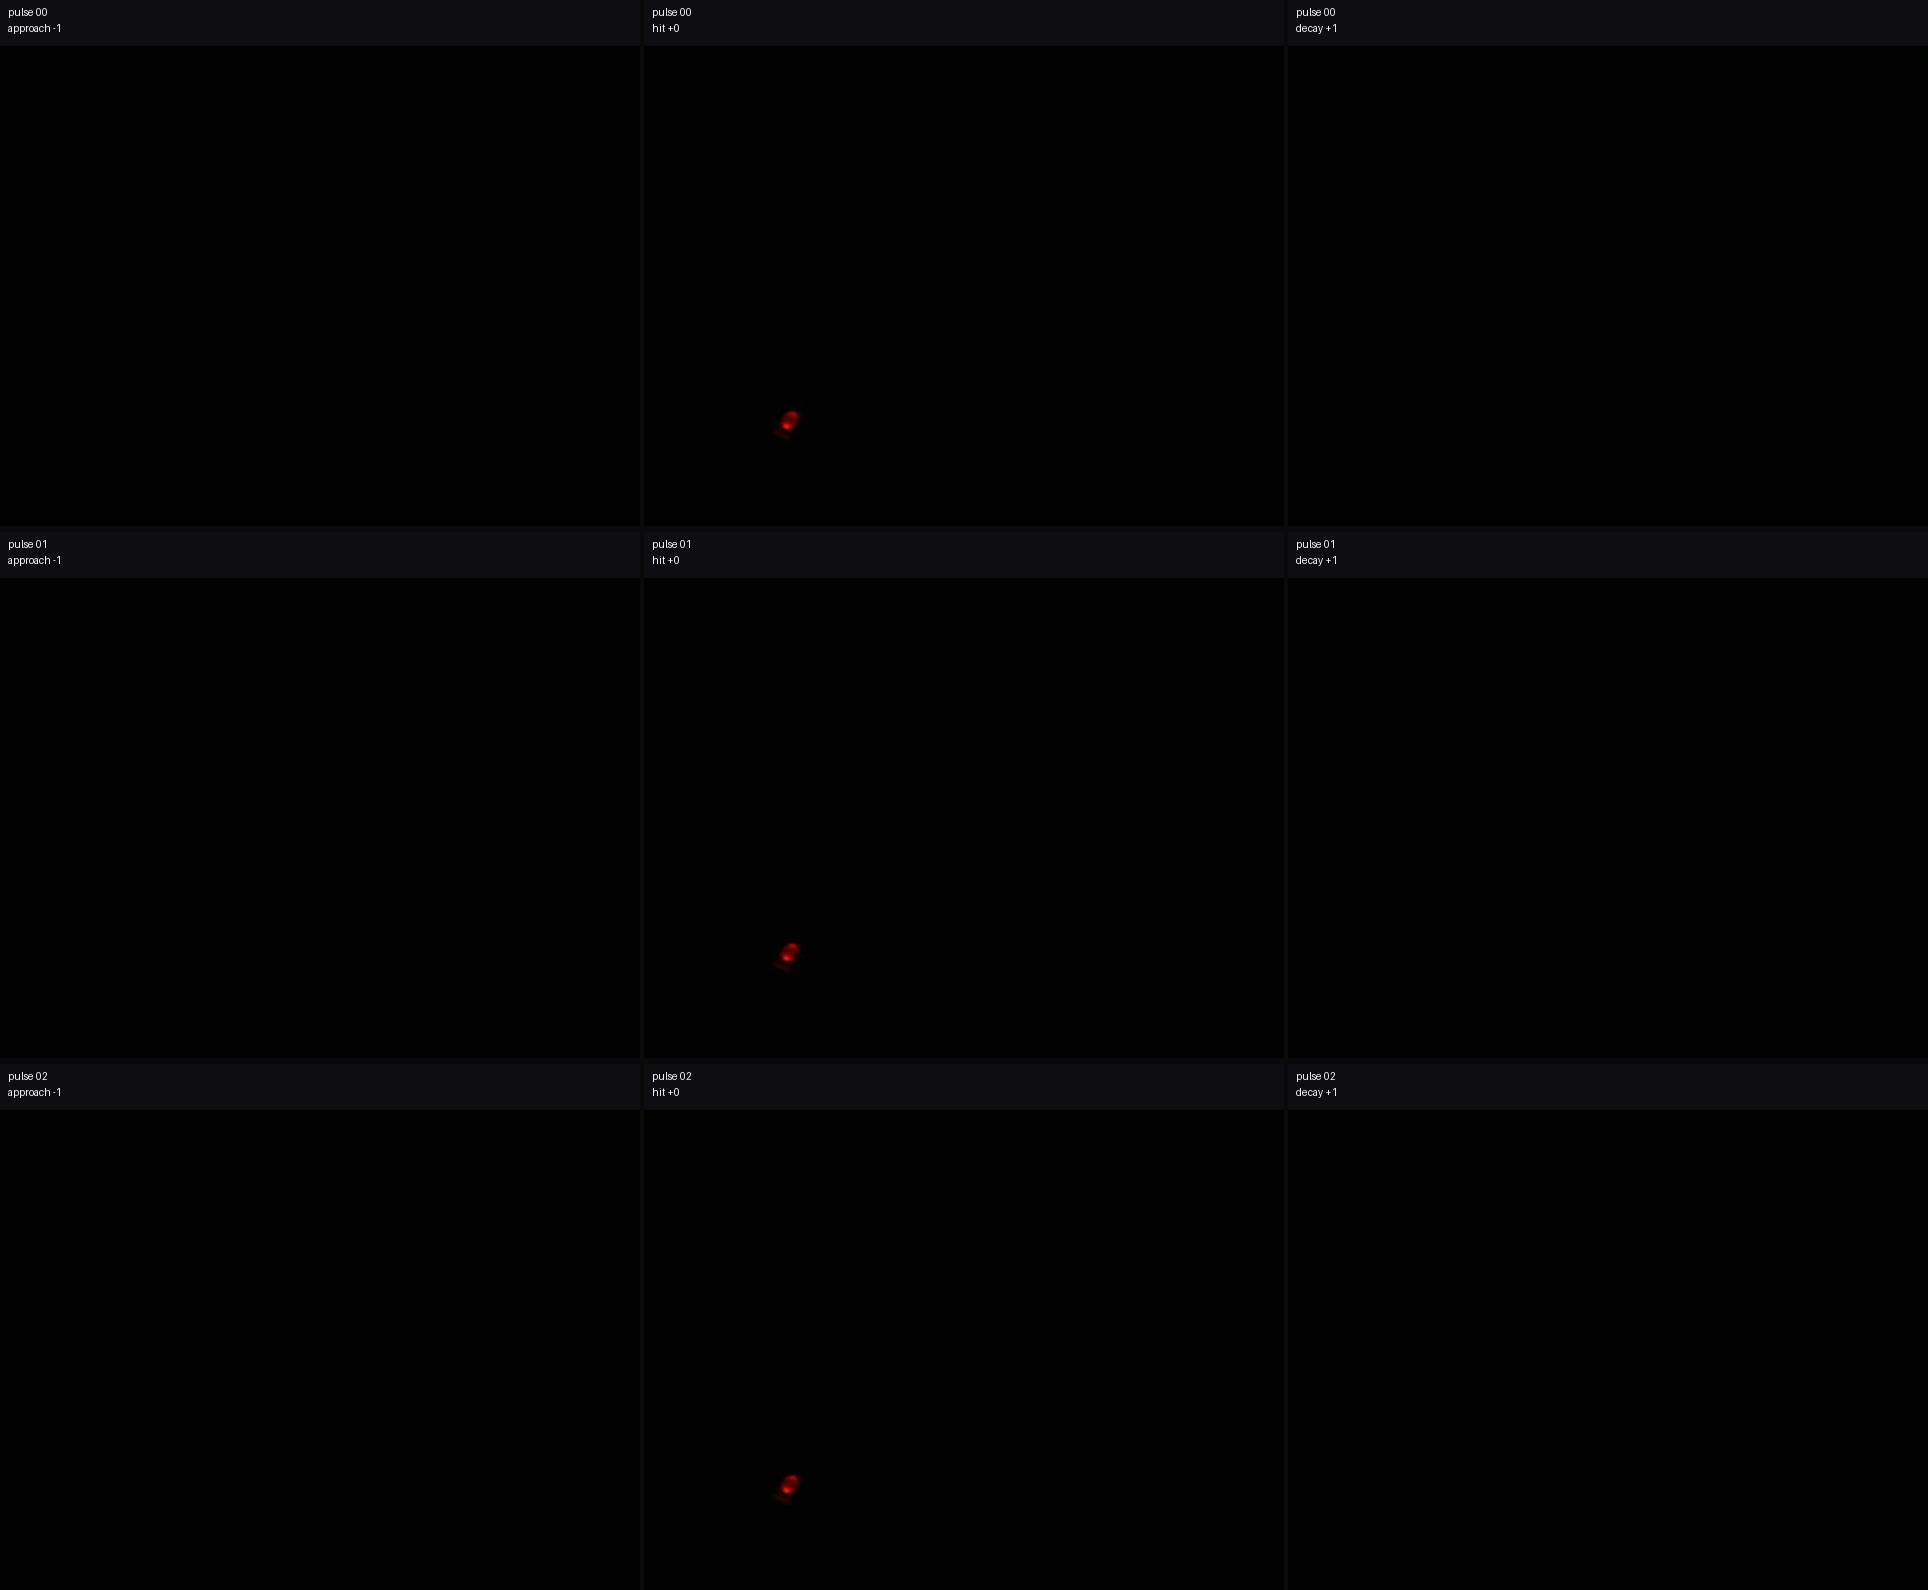

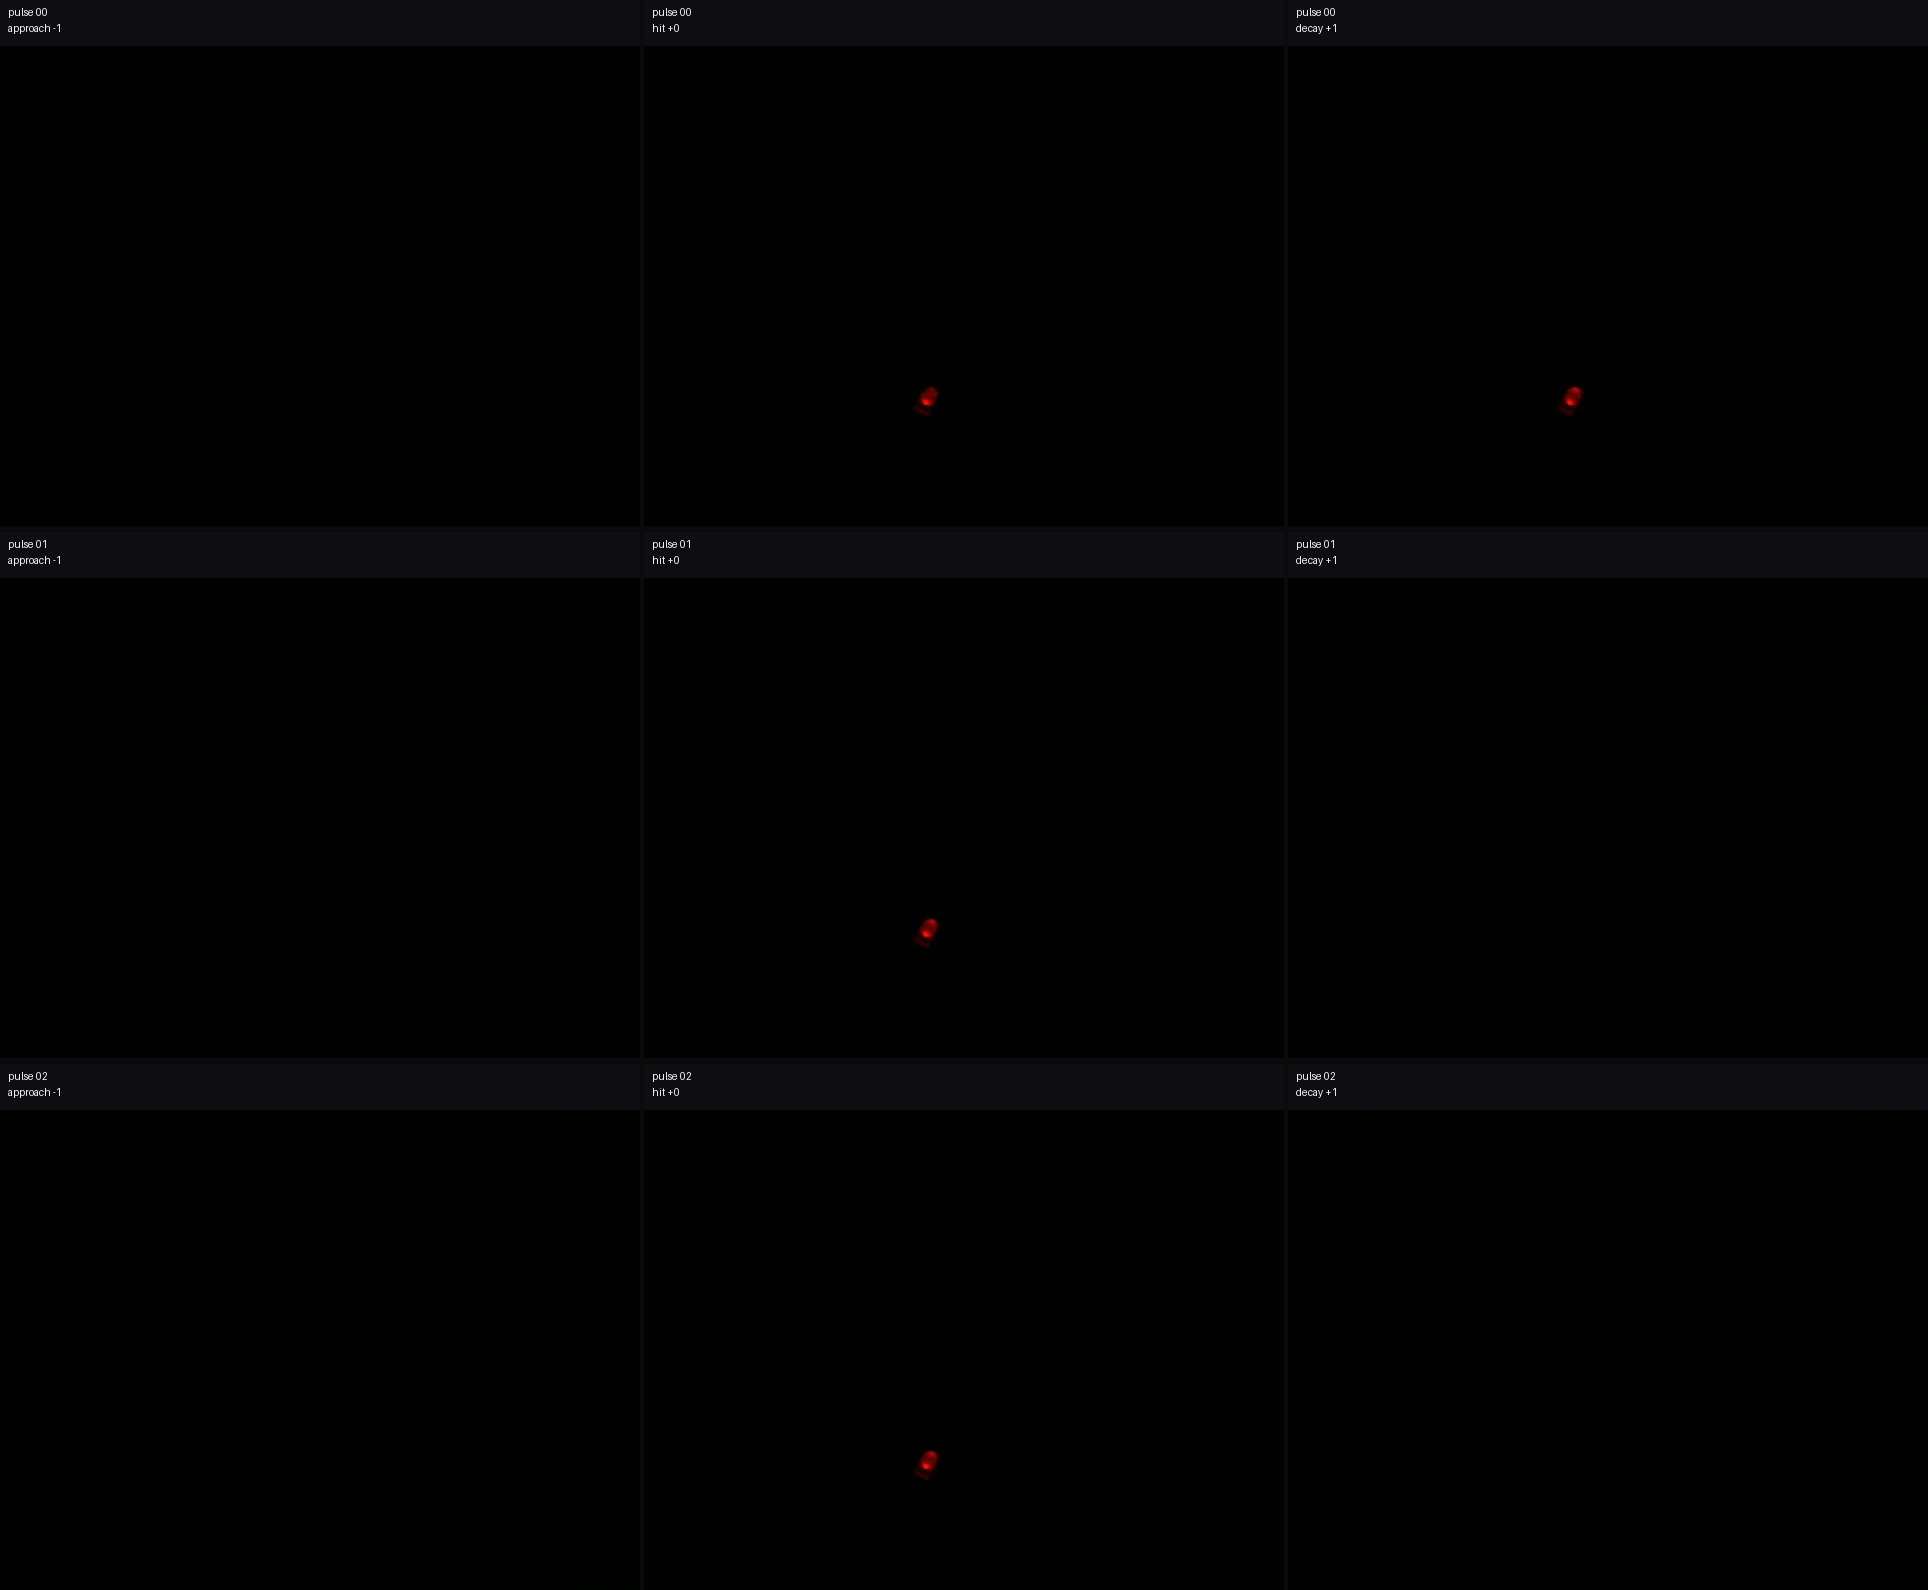

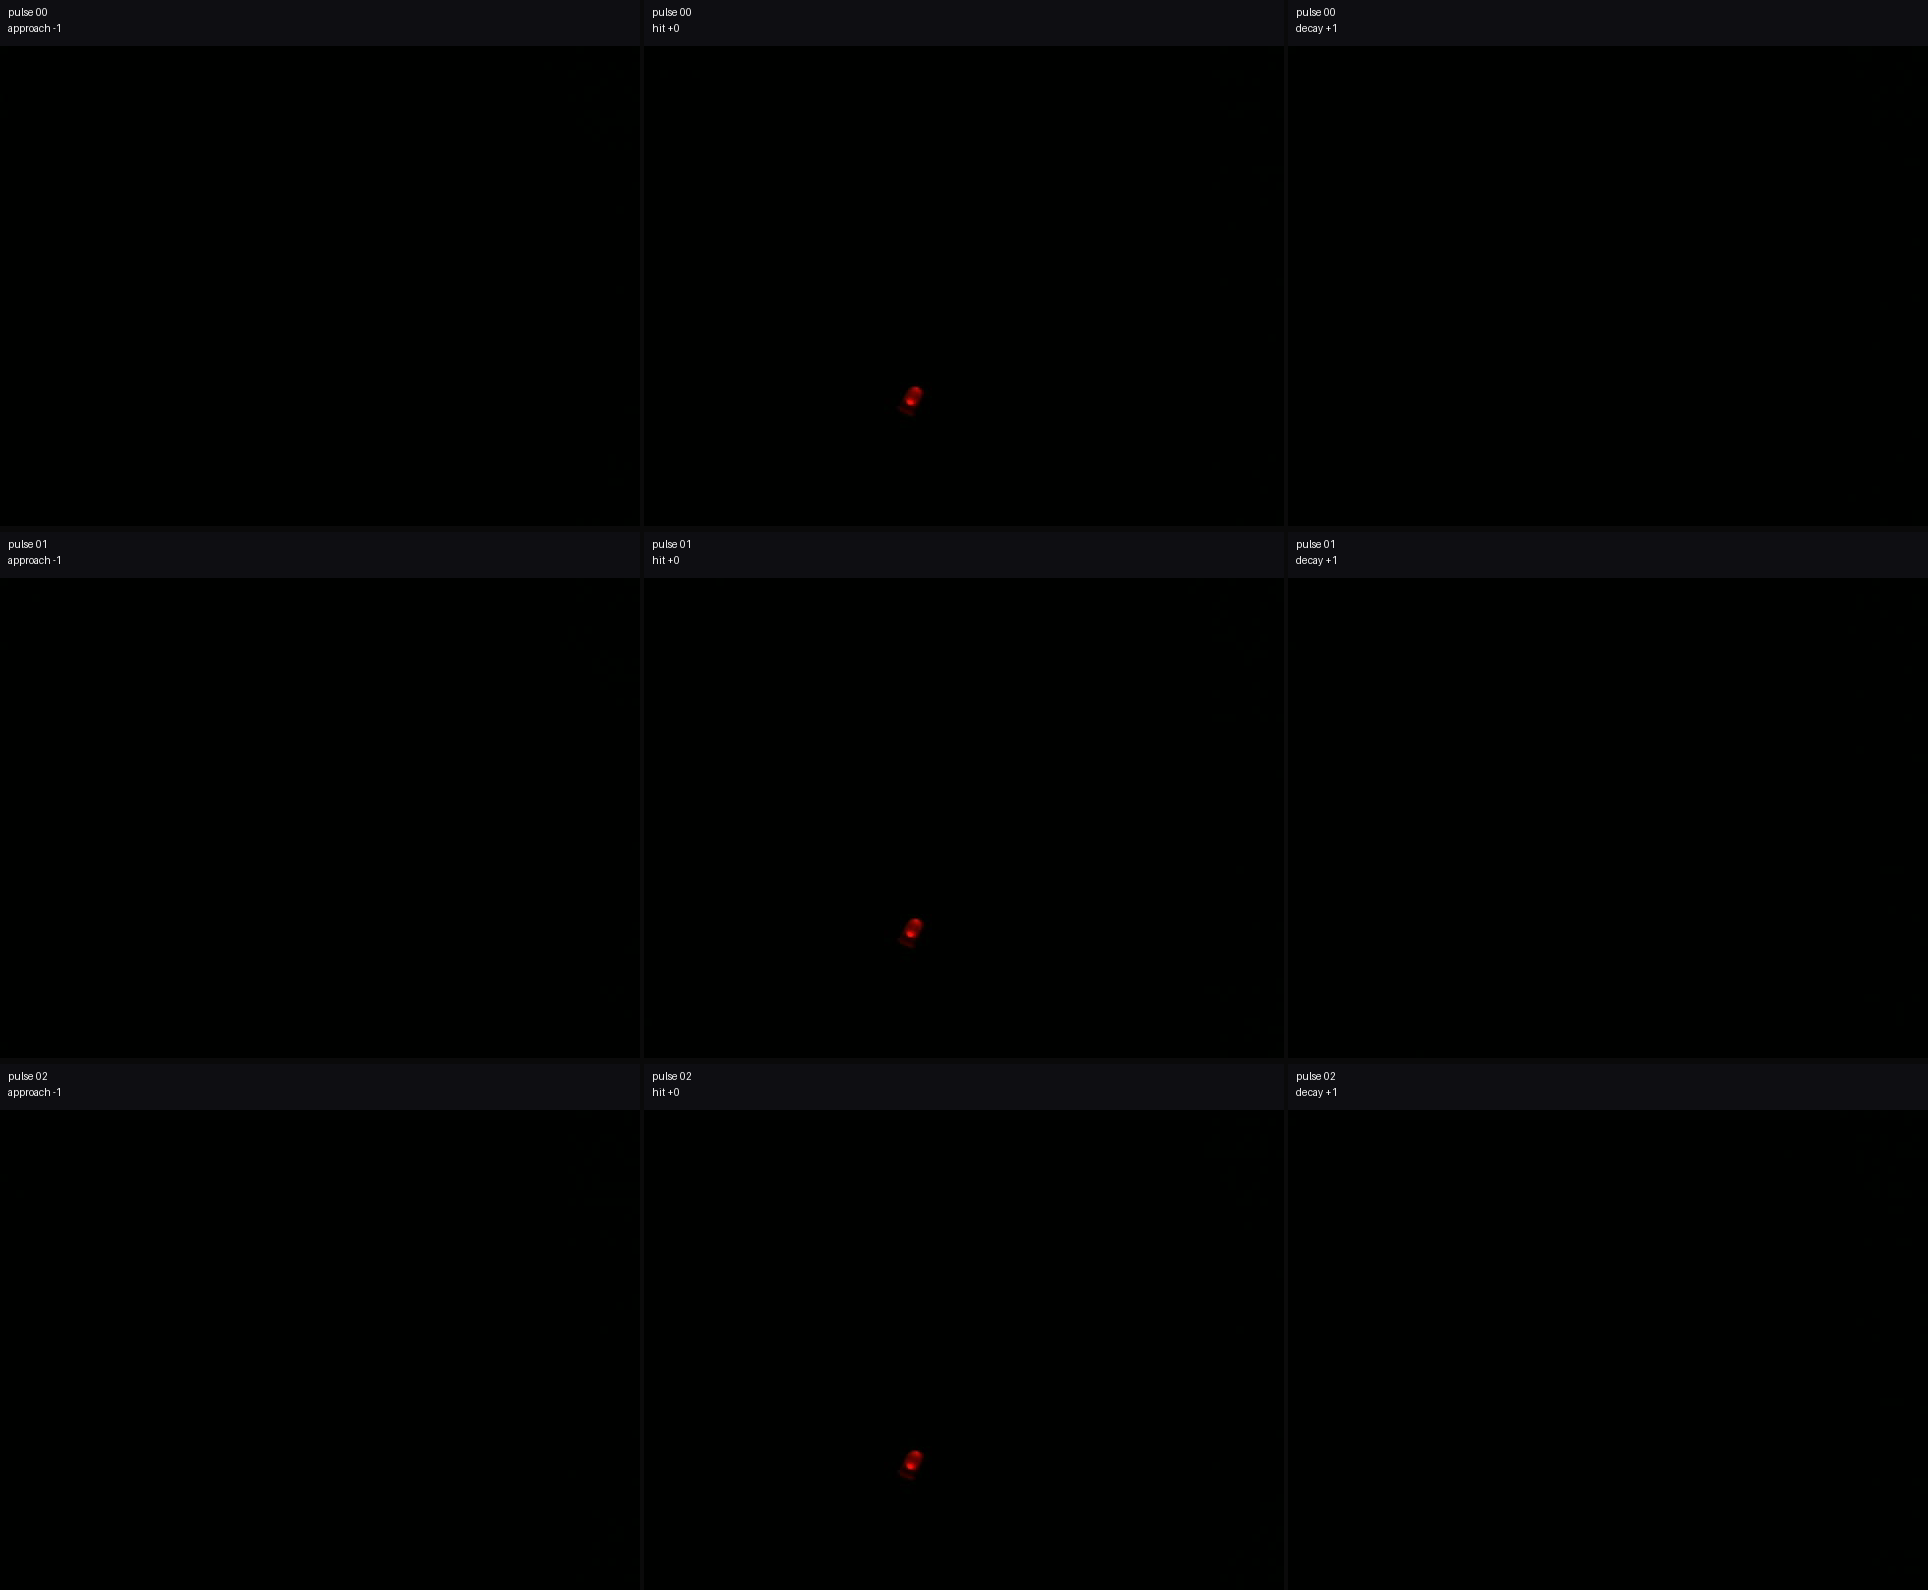

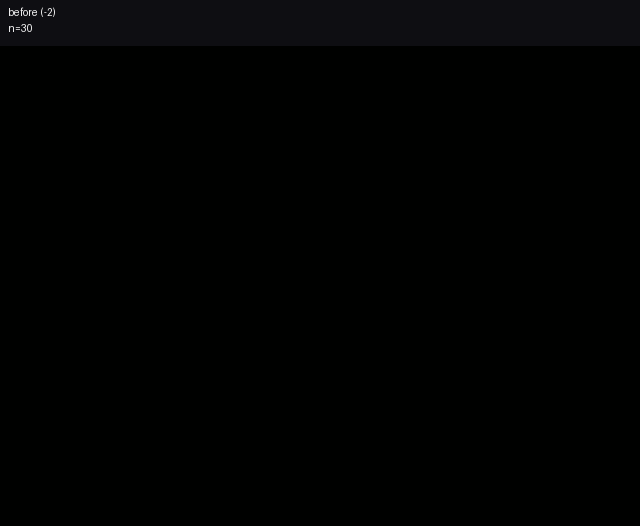

# Confidence and coverage notes for the reconstruction

## How each image was built

1. Select the best dual random-train runs with full webcam coverage and non-zero matched detections.
2. For each matched pulse, extract webcam frames at relative offsets `-2, -1, 0, +1, +2` around the matched frame.
3. Average pixel-wise within each relative phase to obtain `before`, `approach`, `hit`, `decay`, and `after` views.
4. Create contrast-normalized previews from those averages so the repeated flash pattern is visible without claiming radiometric calibration.
5. Report quantitative deltas against the pooled `before` phase in `reconstruction_statistics.csv`.

## Coverage and confidence annotations

- Selected runs: `3`.
- Matched pulses contributing to the pooled reconstruction: `30`.
- Effective sample size across runs (Kish-style by matched-pulse contribution): `3.00`.
- Pooled coincidence rate on covered windows: `1.000` with Wilson 95% CI `[0.886, 1.000]`.
- Pooled mean matched-frame offset: `36.98 ms`.

## Run-level variability at the hit phase

| run_id                       |   matched_pulses |   coverage_fraction |   coincidence_success_rate_windowed |   coincidence_success_ci_low |   coincidence_success_ci_high |   mean_offset_ms_detected |   offset_std_ms_detected |
|:-----------------------------|-----------------:|--------------------:|------------------------------------:|-----------------------------:|------------------------------:|--------------------------:|-------------------------:|
| random-train_20260522_162947 |               10 |                   1 |                                   1 |                      0.72246 |                             1 |                   39.397  |                  7.25788 |
| random-train_20260522_163706 |               10 |                   1 |                                   1 |                      0.72246 |                             1 |                   32.1117 |                 11.2914  |
| random-train_20260522_172025 |               10 |                   1 |                                   1 |                      0.72246 |                             1 |                   39.4449 |                 10.3586  |

## Interpretation discipline

- Higher `frame_count` means more repeated evidence contributed to that phase average.
- `effective_sample_size` tells you whether the pooled image comes from several runs or is dominated by one run.
- `delta_mean_gray_vs_before` is a simple summary of how much brighter a phase is than the pooled pre-flash phase; it is useful for interpretability, not for absolute photometry.
- The comparison panel should be read together with the confidence intervals and offset spread, not as standalone proof of high-speed temporal imaging.


# Reconstruction uncertainty and systematic error summary

## Scope of this uncertainty model

- This is an offline, practical uncertainty treatment.
- It combines exact binomial confidence intervals where appropriate with interval-based temporal bounds and sensitivity analyses where exact propagation is not defensible.
- It does NOT claim lab-grade calibration of the webcam, LED output, or the OP598 timing chain.

## Key propagated outputs

- Pooled coincidence success rate on covered windows: `30/30 = 1.000` with Wilson 95% CI `[0.886, 1.000]`.
- Mean matched-frame offset: `37.0 +/- 20.1 ms from interval-based propagation of mean frame half-period and OP598 half sample-interval`.
- Minimum detectable duty statement: `practical conditional threshold is about duty 6-8, not a single exact duty, because the first success point has limited replicates and low-duty exposure response is non-monotonic`.
- Pulse-duration detectability statement: `practical webcam detectability starts around 50-100 ms depending on duty and exposure, with no evidence for a stable sub-50 ms threshold in the current dataset`.

## Systematic error terms included

- Webcam temporal quantization: mean half-frame uncertainty about `16.74 ms` from the selected runs' measured FPS.
- OP598 temporal anchoring under MicroPython cadence: mean half sample-interval about `3.32 ms` from `op598.sample_interval_avg_ms`.
- Threshold sensitivity: recomputed retained coincidence under stricter matched-frame thresholds of +10% and +20% using stored frame-threshold margins.
- Exposure dependence / low-duty non-monotonicity: low-duty exposure sweep spans `1.000` probability units, so the webcam threshold is conditional on exposure rather than monotonic.
- OP598 saturation: duties with saturation evidence in the characterization table: `[128, 512, 1023]`.
- Limited replicate counts: current derived tables mostly sit between `1` and `3` replicates per condition, often only one.

## Threshold sensitivity results

|   threshold_delta_fraction |   covered_pulses |   retained_matches |   retained_rate |
|---------------------------:|-----------------:|-------------------:|----------------:|
|                        0.1 |               30 |                 30 |               1 |
|                        0.2 |               30 |                 30 |               1 |

Interpretation: this is a one-sided robustness check against stricter thresholds. It does not re-run the full detector or estimate false-positive risk at lower thresholds, so it should be read as sensitivity, not absolute truth.

## Temporal uncertainty inputs by selected run

| run_id                       |   webcam_frame_period_ms |   webcam_half_period_ms |   op598_sample_interval_ms |   op598_half_sample_interval_ms |
|:-----------------------------|-------------------------:|------------------------:|---------------------------:|--------------------------------:|
| random-train_20260522_172025 |                  33.4742 |                 16.7371 |                    6.63502 |                         3.31751 |
| random-train_20260522_163706 |                  33.4738 |                 16.7369 |                    6.6462  |                         3.3231  |
| random-train_20260522_162947 |                  33.474  |                 16.737  |                    6.64585 |                         3.32293 |

## Honest limitations

- Stored offline artifacts do not preserve every pixel-level decision needed for a full end-to-end Monte Carlo of thresholding and matching.
- Exposure and duration sweeps are sparse, so uncertainty on detectability thresholds is better expressed as bounded practical ranges than precise estimates.
- OP598 saturation at high duty means amplitude-based interpretation there is not reliable, even if coincidence can still be observed.
- The propagated offset bound is conservative and interval-based; it is intentionally easier to defend than a pseudo-precise Gaussian claim.

Auxiliary sensitivity table written to `data/derived/reconstruction/threshold_sensitivity.csv`.


**Takeaway.** La reconstruccion ahora es mas defendible porque junta evidencia visual por fases, comparacion pooled vs por corrida, cantidad de pulsos, IC95% de coincidencia, distribucion de offsets y un resumen explicito de incertidumbre sistematica. Sigue siendo una proxy estadistica, NO filmacion de alta velocidad.

In [7]:
selection_path = reconstruction_base / "best_dual_run_selection.csv"
stats_path = reconstruction_base / "reconstruction_statistics.csv"
overview_path = reconstruction_base / "reconstruction_overview.md"
confidence_notes_path = reconstruction_base / "reconstruction_confidence_notes.md"
uncertainty_path = reconstruction_base / "reconstruction_uncertainty_summary.md"
avg_frame_path = reconstruction_base / "avg_flash_frame.png"
heatmap_path = reconstruction_base / "flash_heatmap.png"
comparison_panel_path = reconstruction_base / "reconstruction_comparison_panel.png"
offset_distribution_path = reconstruction_base / "coincidence_offset_distribution.png"
slowmo_path = reconstruction_base / "slowmo_reconstruction.gif"
pulse_strip_dir = reconstruction_base / "pulse_strips"

selection = pd.read_csv(selection_path)
reconstruction_stats = pd.read_csv(stats_path)
selected = selection.loc[
    selection["selected_for_reconstruction"].astype(str).str.lower() == "true",
    [
        "selection_rank",
        "run_id",
        "variant",
        "covered_pulses",
        "matched_detected",
        "coincidence_success_rate_windowed",
        "mean_offset_ms_detected",
    ],
].sort_values("selection_rank")
display(selected)
display(reconstruction_stats.loc[reconstruction_stats["group_id"] == "pooled"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
axes[0].imshow(plt.imread(avg_frame_path))
axes[0].set_title("Promedio de frames emparejados")
axes[0].axis("off")

axes[1].imshow(plt.imread(heatmap_path))
axes[1].set_title("Mapa acumulado matched - before")
axes[1].axis("off")

display(fig)
plt.close(fig)

display(DisplayImage(filename=str(comparison_panel_path)))
display(DisplayImage(filename=str(offset_distribution_path)))

for strip_path in sorted(pulse_strip_dir.glob("*.png")):
    display(DisplayImage(filename=str(strip_path)))

display(DisplayImage(filename=str(slowmo_path)))
display(Markdown(confidence_notes_path.read_text(encoding="utf-8")))
display(Markdown(uncertainty_path.read_text(encoding="utf-8")))

display(
    Markdown(
        "**Takeaway.** La reconstruccion ahora es mas defendible porque junta evidencia visual por fases, comparacion pooled vs por corrida, cantidad de pulsos, IC95% de coincidencia, distribucion de offsets y un resumen explicito de incertidumbre sistematica. Sigue siendo una proxy estadistica, NO filmacion de alta velocidad."
    )
)


## Incertidumbre y errores sistematicos

Si queres defender esto cientificamente, ACA ESTA la parte que no se puede esquivar: cuantizacion temporal webcam, anclaje OP598 bajo MicroPython, sensibilidad al umbral, dependencia con exposicion, saturacion y pocas replicas.


In [8]:
uncertainty_path = reconstruction_base / "reconstruction_uncertainty_summary.md"
display(Markdown(uncertainty_path.read_text(encoding="utf-8")))


# Reconstruction uncertainty and systematic error summary

## Scope of this uncertainty model

- This is an offline, practical uncertainty treatment.
- It combines exact binomial confidence intervals where appropriate with interval-based temporal bounds and sensitivity analyses where exact propagation is not defensible.
- It does NOT claim lab-grade calibration of the webcam, LED output, or the OP598 timing chain.

## Key propagated outputs

- Pooled coincidence success rate on covered windows: `30/30 = 1.000` with Wilson 95% CI `[0.886, 1.000]`.
- Mean matched-frame offset: `37.0 +/- 20.1 ms from interval-based propagation of mean frame half-period and OP598 half sample-interval`.
- Minimum detectable duty statement: `practical conditional threshold is about duty 6-8, not a single exact duty, because the first success point has limited replicates and low-duty exposure response is non-monotonic`.
- Pulse-duration detectability statement: `practical webcam detectability starts around 50-100 ms depending on duty and exposure, with no evidence for a stable sub-50 ms threshold in the current dataset`.

## Systematic error terms included

- Webcam temporal quantization: mean half-frame uncertainty about `16.74 ms` from the selected runs' measured FPS.
- OP598 temporal anchoring under MicroPython cadence: mean half sample-interval about `3.32 ms` from `op598.sample_interval_avg_ms`.
- Threshold sensitivity: recomputed retained coincidence under stricter matched-frame thresholds of +10% and +20% using stored frame-threshold margins.
- Exposure dependence / low-duty non-monotonicity: low-duty exposure sweep spans `1.000` probability units, so the webcam threshold is conditional on exposure rather than monotonic.
- OP598 saturation: duties with saturation evidence in the characterization table: `[128, 512, 1023]`.
- Limited replicate counts: current derived tables mostly sit between `1` and `3` replicates per condition, often only one.

## Threshold sensitivity results

|   threshold_delta_fraction |   covered_pulses |   retained_matches |   retained_rate |
|---------------------------:|-----------------:|-------------------:|----------------:|
|                        0.1 |               30 |                 30 |               1 |
|                        0.2 |               30 |                 30 |               1 |

Interpretation: this is a one-sided robustness check against stricter thresholds. It does not re-run the full detector or estimate false-positive risk at lower thresholds, so it should be read as sensitivity, not absolute truth.

## Temporal uncertainty inputs by selected run

| run_id                       |   webcam_frame_period_ms |   webcam_half_period_ms |   op598_sample_interval_ms |   op598_half_sample_interval_ms |
|:-----------------------------|-------------------------:|------------------------:|---------------------------:|--------------------------------:|
| random-train_20260522_172025 |                  33.4742 |                 16.7371 |                    6.63502 |                         3.31751 |
| random-train_20260522_163706 |                  33.4738 |                 16.7369 |                    6.6462  |                         3.3231  |
| random-train_20260522_162947 |                  33.474  |                 16.737  |                    6.64585 |                         3.32293 |

## Honest limitations

- Stored offline artifacts do not preserve every pixel-level decision needed for a full end-to-end Monte Carlo of thresholding and matching.
- Exposure and duration sweeps are sparse, so uncertainty on detectability thresholds is better expressed as bounded practical ranges than precise estimates.
- OP598 saturation at high duty means amplitude-based interpretation there is not reliable, even if coincidence can still be observed.
- The propagated offset bound is conservative and interval-based; it is intentionally easier to defend than a pseudo-precise Gaussian claim.

Auxiliary sensitivity table written to `data/derived/reconstruction/threshold_sensitivity.csv`.


## Que se puede y que no se puede afirmar

**Si se puede afirmar con respaldo de estos datos**
- La detectabilidad de flashes con webcam depende fuertemente de duty, duracion y exposicion.
- El canal OP598 detecta variaciones utiles a bajo duty, pero satura rapido al crecer la excitacion.
- El pipeline dual ya permite medir coincidencia entre pulsos LED y frames detectados.
 - La reconstruccion estadistica por coincidencias permite generar una proxy visual acumulada y un slow motion sintetico del evento.
 - La nueva salida de incertidumbre ya no vende precision falsa: expresa CI binomial, sensibilidad al umbral y limites temporales como intervalos practicos.

**No se debe sobreafirmar**
- Estos resultados NO prueban todavia deteccion de curvas de Lissajous reales.
 - La webcam NO resuelve dinamica temporal fina como lo haria una camara de alta velocidad.
 - Los tiempos OP598 observados reflejan la cadena `LED + optica + OP598 + ADC + ESP32 + MicroPython`, no la respuesta intrinseca aislada del fototransistor.
 - El GIF reconstruido NO representa frames reales consecutivos de un unico destello; son promedios relativos alrededor de muchas coincidencias.
 - Los umbrales de duty y duracion detectables siguen siendo condicionales al pipeline actual y a pocas replicas.


## Conclusiones finales y siguiente trabajo

**Conclusiones**
- El material derivado actual ya alcanza para una exposicion honesta sobre detectabilidad de destellos.
- La webcam sirve como evidencia visual y de detectabilidad gruesa, especialmente cuando el pulso es suficientemente largo o la integracion del frame ayuda.
- El canal OP598 es mejor para seguir la respuesta analogica, aunque hoy esta limitado por saturacion y por el tiempo de muestreo efectivo bajo MicroPython.
- La coincidencia dual es la pieza mas prometedora para enlazar ambos mundos en futuras defensas del proyecto.
 - La nueva reconstruccion estadistica agrega una pieza de narrativa visual mucho mas clara para presentacion offline, sin vender humo sobre imagen rapida directa.
 - El tratamiento de incertidumbre ahora deja explicito que varias conclusiones deben leerse como rangos practicos y no como precision fisica fina.

**Proximo trabajo recomendado**
1. Repetir condiciones clave con mas replicas por punto para mejorar respaldo estadistico.
2. Diseñar corridas duales con cobertura webcam garantizada de inicio a fin.
3. Explorar electronica o firmware con mejor resolucion temporal si la pregunta pasa de detectabilidad a temporizacion fina.
